In [4]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

ROOT = Path.cwd().parents[0]   # notebook inside notebooks/
PROCESSED_DIR = ROOT / "data" / "processed"
REPORTS_DIR = ROOT / "reports" / "metrics"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 28
N_WINDOWS = 3          # impressive default
GAP_DAYS = 28          # step size between windows (28 = non-overlapping)

# Optional speed toggle (use False for full run)
FAST_DEV = False

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), eps)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)

def wape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sum(np.abs(y_true - y_pred)) / np.maximum(np.sum(np.abs(y_true)), eps) * 100.0)

In [5]:
df = pd.read_parquet(PROCESSED_DIR / "features.parquet")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["id", "date"])

print("features:", df.shape, "date range:", df["date"].min().date(), "→", df["date"].max().date())

# target
y_all = df["y"].astype(np.float32)

# same feature selection logic you used in training
drop_cols = {"y", "date", "d", "wm_yr_wk"}
X_all = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore").copy()

# categorical columns (LightGBM can handle pandas category)
cat_cols = ["item_id","dept_id","cat_id","store_id","state_id",
            "event_name_1","event_type_1","event_name_2","event_type_2"]
for c in cat_cols:
    if c in X_all.columns:
        X_all[c] = X_all[c].astype("category")

# avoid series-id leakage / overfit
if "id" in X_all.columns:
    X_all = X_all.drop(columns=["id"])

print("X:", X_all.shape)

features: (57473650, 29) date range: 2011-02-26 → 2016-04-24
X: (57473650, 24)


In [6]:
if FAST_DEV:
    # sample a subset of series to speed up experimentation
    keep_ids = df["item_id"].cat.categories[:2000] if "item_id" in df.columns and str(df["item_id"].dtype)=="category" else df["item_id"].unique()[:2000]
    mask = df["item_id"].isin(keep_ids)
    df = df[mask].copy()
    y_all = df["y"].astype(np.float32)
    X_all = X_all.loc[df.index]
    print("FAST_DEV subset:", df.shape, X_all.shape)

In [7]:
max_date = df["date"].max()
results = []
all_preds = []  # optional: store per-row predictions for plotting/analysis

for w in range(N_WINDOWS):
    # window moves backwards in chunks of GAP_DAYS
    window_end = max_date - pd.Timedelta(days=w * GAP_DAYS)
    window_start = window_end - pd.Timedelta(days=HORIZON - 1)

    train_idx = df["date"] < window_start
    valid_idx = (df["date"] >= window_start) & (df["date"] <= window_end)

    X_train, y_train = X_all.loc[train_idx], y_all.loc[train_idx]
    X_valid, y_valid = X_all.loc[valid_idx], y_all.loc[valid_idx]

    print(f"\nWindow {w+1}/{N_WINDOWS}: {window_start.date()} → {window_end.date()}")
    print("Train:", X_train.shape, "Valid:", X_valid.shape)

    # model (tune if needed; keeping close to your baseline)
    model = lgb.LGBMRegressor(
        n_estimators=1200 if not FAST_DEV else 800,
        learning_rate=0.03,
        num_leaves=128,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        force_row_wise=True
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="l1",
        callbacks=[
            lgb.log_evaluation(period=200),
            lgb.early_stopping(stopping_rounds=100, verbose=True)
        ]
    )

    pred = model.predict(X_valid).astype(np.float32)
    pred = np.maximum(0, pred)

    mae = float(mean_absolute_error(y_valid, pred))
    rmse = float(np.sqrt(mean_squared_error(y_valid, pred)))
    sm = smape(y_valid, pred)
    wp = wape(y_valid, pred)

    results.append({
        "window": w+1,
        "valid_start": str(window_start.date()),
        "valid_end": str(window_end.date()),
        "n_train": int(X_train.shape[0]),
        "n_valid": int(X_valid.shape[0]),
        "n_features": int(X_train.shape[1]),
        "best_iteration": int(getattr(model, "best_iteration_", model.n_estimators)),
        "mae": mae,
        "rmse": rmse,
        "smape": sm,
        "wape": wp
    })

    # Save per-row predictions for deeper analysis / dashboard (optional but impressive)
    tmp = df.loc[valid_idx, ["item_id","store_id","dept_id","cat_id","state_id","date","y"]].copy()
    tmp["yhat"] = pred
    tmp["window"] = w+1
    all_preds.append(tmp)

bt_df = pd.DataFrame(results).sort_values("window")
bt_df


Window 1/3: 2016-03-28 → 2016-04-24
Train: (56619930, 24) Valid: (853720, 24)
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Total Bins 4654
[LightGBM] [Info] Number of data points in the train set: 56619930, number of used features: 24
[LightGBM] [Info] Start training from score 1.126407
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l1: 1.02127	valid_0's l2: 3.90022
[400]	valid_0's l1: 1.00895	valid_0's l2: 3.83492
[600]	valid_0's l1: 1.0043	valid_0's l2: 3.80569
[800]	valid_0's l1: 1.00277	valid_0's l2: 3.78487
[1000]	valid_0's l1: 1.00082	valid_0's l2: 3.77242
[1200]	valid_0's l1: 0.999635	valid_0's l2: 3.76193
Did not meet early stopping. Best iteration is:
[1200]	valid_0's l1: 0.999635	valid_0's l2: 3.76193

Window 2/3: 2016-02-29 → 2016-03-27
Train:

,window,valid_start,valid_end,n_train,n_valid,n_features,best_iteration,mae,rmse,smape,wape
0,1,2016-03-28,2016-04-24,56619930,853720,24,1200,0.999629,1.939565,142.051129,72.100774
1,2,2016-02-29,2016-03-27,55766210,853720,24,1200,1.000846,2.008525,143.700159,72.652483
2,3,2016-02-01,2016-02-28,54912490,853720,24,1199,1.001383,2.051769,145.040747,72.716213


In [8]:
# summary table
bt_path = REPORTS_DIR / "backtest_summary.parquet"
bt_df.to_parquet(bt_path, index=False)

# per-row predictions
preds = pd.concat(all_preds, ignore_index=True)
preds_path = REPORTS_DIR / "backtest_predictions.parquet"
preds.to_parquet(preds_path, index=False)

# json for README
bt_json_path = REPORTS_DIR / "backtest_summary.json"
bt_json_path.write_text(json.dumps(results, indent=2), encoding="utf-8")

print("✅ saved:", bt_path)
print("✅ saved:", preds_path)
print("✅ saved:", bt_json_path)

✅ saved: /Users/sohithmalyala/Desktop/Projects/demand-forecasting-platform/reports/metrics/backtest_summary.parquet
✅ saved: /Users/sohithmalyala/Desktop/Projects/demand-forecasting-platform/reports/metrics/backtest_predictions.parquet
✅ saved: /Users/sohithmalyala/Desktop/Projects/demand-forecasting-platform/reports/metrics/backtest_summary.json


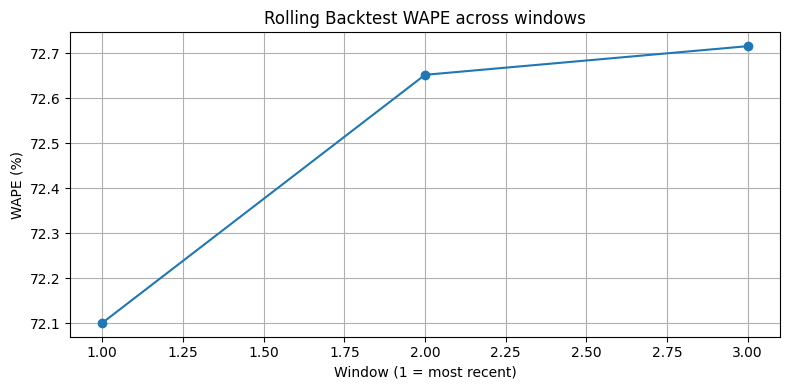

,window,valid_start,valid_end,mae,rmse,wape,smape,best_iteration
0,1,2016-03-28,2016-04-24,0.999629,1.939565,72.100774,142.051129,1200
1,2,2016-02-29,2016-03-27,1.000846,2.008525,72.652483,143.700159,1200
2,3,2016-02-01,2016-02-28,1.001383,2.051769,72.716213,145.040747,1199


In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(bt_df["window"], bt_df["wape"], marker="o")
plt.title("Rolling Backtest WAPE across windows")
plt.xlabel("Window (1 = most recent)")
plt.ylabel("WAPE (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

bt_df[["window","valid_start","valid_end","mae","rmse","wape","smape","best_iteration"]]

In [10]:
bt_df

,window,valid_start,valid_end,n_train,n_valid,n_features,best_iteration,mae,rmse,smape,wape
0,1,2016-03-28,2016-04-24,56619930,853720,24,1200,0.999629,1.939565,142.051129,72.100774
1,2,2016-02-29,2016-03-27,55766210,853720,24,1200,1.000846,2.008525,143.700159,72.652483
2,3,2016-02-01,2016-02-28,54912490,853720,24,1199,1.001383,2.051769,145.040747,72.716213


In [11]:
bt_df[["mae", "rmse", "wape", "smape"]].mean()

mae        1.000619
rmse       1.999953
wape      72.489824
smape    143.597345
dtype: float64

In [12]:
# Evaluate baselines on same validation windows

baseline_results = []

for w in range(len(all_preds)):
    
    window_preds = all_preds[w].copy()
    
    # merge lag features
    window_data = df.merge(
        window_preds[["item_id","store_id","date"]],
        on=["item_id","store_id","date"],
        how="right"
    )
    
    y_true = window_data["y"]
    
    # Naive baseline
    naive_pred = window_data["lag_1"]
    
    # Seasonal naive baseline
    seasonal_pred = window_data["lag_7"]
    
    from sklearn.metrics import mean_absolute_error
    
    naive_mae = mean_absolute_error(y_true, naive_pred)
    seasonal_mae = mean_absolute_error(y_true, seasonal_pred)
    
    baseline_results.append({
        "window": w+1,
        "naive_mae": naive_mae,
        "seasonal_naive_mae": seasonal_mae
    })

baseline_df = pd.DataFrame(baseline_results)
baseline_df

,window,naive_mae,seasonal_naive_mae
0,1,1.179817,1.205352
1,2,1.169802,1.201650
2,3,1.164297,1.206481


In [13]:
comparison = bt_df.merge(baseline_df, on="window")

comparison[[
    "window",
    "mae",
    "naive_mae",
    "seasonal_naive_mae"
]]

,window,mae,naive_mae,seasonal_naive_mae
0,1,0.999629,1.179817,1.205352
1,2,1.000846,1.169802,1.201650
2,3,1.001383,1.164297,1.206481


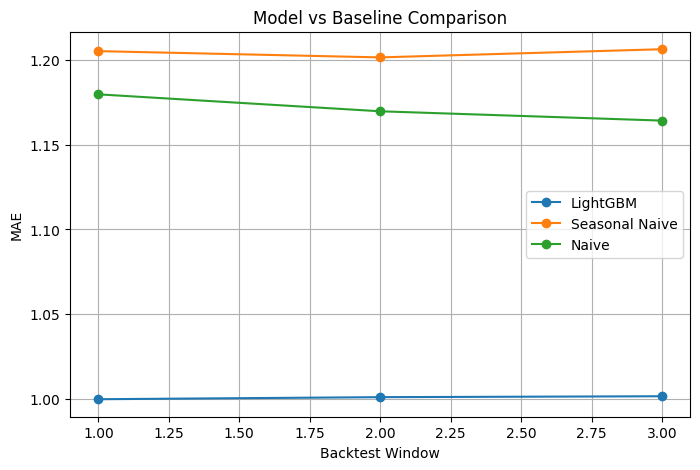

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(comparison["window"], comparison["mae"], marker="o", label="LightGBM")
plt.plot(comparison["window"], comparison["seasonal_naive_mae"], marker="o", label="Seasonal Naive")
plt.plot(comparison["window"], comparison["naive_mae"], marker="o", label="Naive")

plt.xlabel("Backtest Window")
plt.ylabel("MAE")
plt.title("Model vs Baseline Comparison")
plt.legend()
plt.grid(True)

plt.show()